## Notation
Here is a summary of some of the notation you will encounter.

| General <img width="70"/> <br/> Notation <img width="70"/> | Description <img width="350"/> | Python (if applicable) |
|:--|:--|:--|
| $a$ | scalar, non bold |  |
| $\mathbf{a}$ | vector, bold |  |
| **Regression** |  |  |
| $\mathbf{x}$ | Training example feature values (in this lab: Size (1000 sqft)) | `x_train` |
| $\mathbf{y}$ | Training example targets (in this lab: Price (1000s of dollars)) | `y_train` |
| $x^{(i)}$, $y^{(i)}$ | $i_{th}$ training example | `x_i`, `y_i` |
| $m$ | Number of training examples | `m` |
| $w$ | parameter: weight | `w` |
| $b$ | parameter: bias | `b` |
| $f_{w,b}(x^{(i)})$ | Model evaluation at $x^{(i)}$: $f_{w,b}(x^{(i)}) = wx^{(i)} + b$ | `f_wb` |


In [18]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x_train = np.array([1.0, 3.0]) # input variable (size in 1000 sqft)
y_train = np.array([300, 500]) # output variable (price in $1000's)

print(f"x_train: {x_train}")
print(f"y_train: {y_train}")

x_train: [1. 3.]
y_train: [300 500]


In [20]:
# Get the number of training examples
print(x_train.shape)
m = x_train.shape[0]
print(f"Number of training examples, m = {m}")

(2,)
Number of training examples, m = 2


In [21]:
# Training examples
print("Training examples")
for i in range(m):
    x_i = x_train[i]
    y_i = y_train[i]
    
    print(f"x^({i}), y^({i}) == ({x_i}, {y_i})")

Training examples
x^(0), y^(0) == (1.0, 300)
x^(1), y^(1) == (3.0, 500)


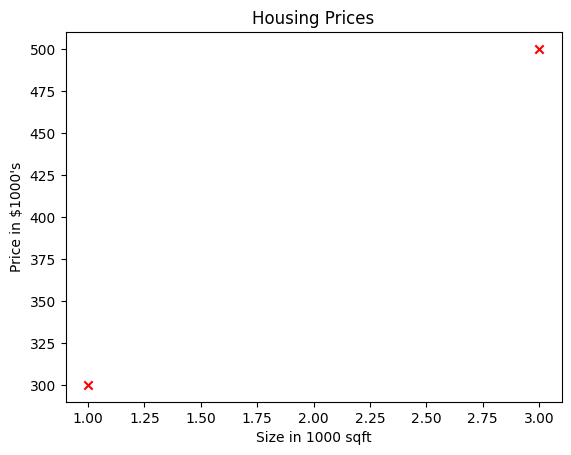

In [22]:
# Plotting the data

plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel("Price in $1000's")
plt.xlabel("Size in 1000 sqft")
plt.show()

In [23]:
# Model Function

w = 100
b = 100

print(f"w: {w}")
print(f"b: {b}")

w: 100
b: 100


In [24]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb

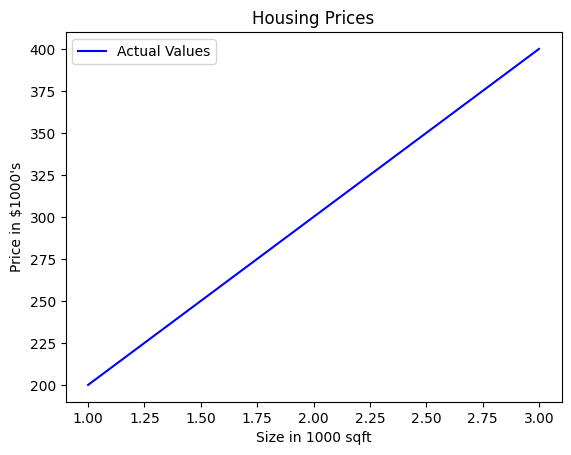

In [25]:
tmp_f_wb = compute_model_output(x_train, w, b)

plt.plot(x_train, tmp_f_wb, c='b', label='Actual Values')
plt.title("Housing Prices")
plt.ylabel("Price in $1000's")
plt.xlabel("Size in 1000 sqft")
plt.legend()
plt.show()

In [26]:
# Supposed we want to predict the price of a house with 1200 sqft in size using our model

w = 200
b = 100
x_i = 1.2  # 1200/1000

f_wb = w * x_i + b

print(f"Price: ${f_wb} thousand dollars")

Price: $340.0 thousand dollars


# GRADIENT DESCENT WITH ONE VARIABLE

### --> COST FUNCTION

In [41]:
x_train = np.array([1.0, 2.0]) # input variable (size in 1000 sqft)
y_train = np.array([300, 500]) # output variable (price in $1000's)

In [42]:
def compute_cost(x, y, w, b):

    cost_sum = 0
    m = x.shape[0]
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i])**2
        cost_sum = cost_sum + cost
    total_cost = (1/(2*m)) * cost_sum

    return total_cost


In [43]:
compute_cost(x_train, y_train, w=200, b=100)

np.float64(0.0)

### --> GRADIENT

In [44]:
def compute_gradient(x, y, w, b) -> tuple:

    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


### --> GRADIENT DESCENT

In [45]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_func, grad_func):

    J_hist = []
    p_hist = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = grad_func(x, y, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Save cost J at each iteration
        if i < 100000:
            J_hist.append(cost_func(x, y, w, b))
            p_hist.append([w,b])

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_hist[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_hist, p_hist #return w and J,w history for graphing

    

In [46]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, cost_func=compute_cost, grad_func=compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 3.41e+00  dj_dw: -3.712e-01, dj_db:  6.007e-01   w:  1.949e+02, b: 1.08228e+02
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 3000: Cost 1.84e-01  dj_dw: -8.625e-02, dj_db:  1.396e-01   w:  1.988e+02, b: 1.01912e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 7000: Cost 5.37e-04  dj_dw: -4.657e-03, dj_db:  7.535e-03   w:  1.999e+02, b: 1.00103e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 9000: Cost 2.90e-05  dj_dw: -1.082e-03, dj_db:  1.751e-03   w:  2.000e+02, b: 1.00024e+02


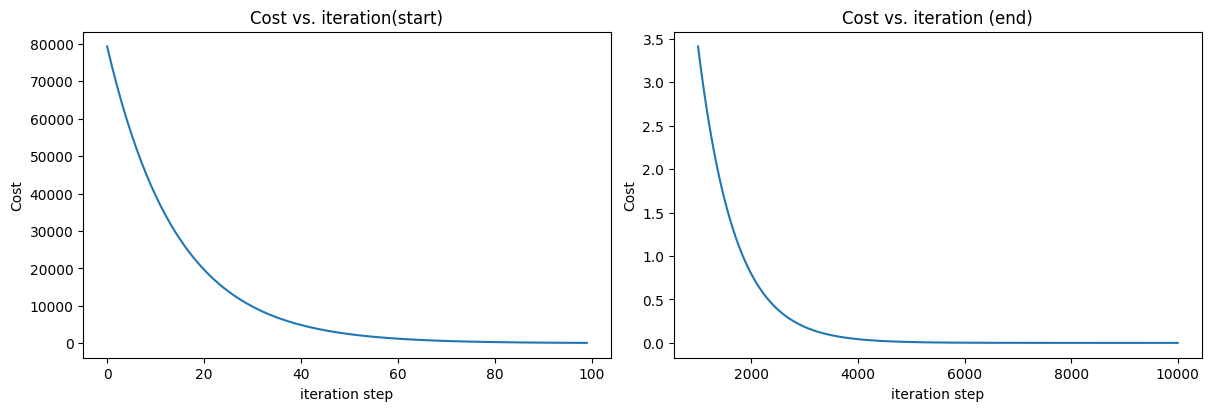

In [47]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [48]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars
